In [1]:
import pandas as pd
import miceforest as mf
import matplotlib.pyplot as plt
import numpy as np
import os
from utils.functions import interp_and_wavg
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer,KNNImputer
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns


%matplotlib qt

In [2]:
os.chdir(r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240805')

In [3]:
df_lab = pd.read_parquet('lab_20240805.parquet')
df_lab.studyId_0831 = df_lab.studyId_0831.astype('uint64')

In [4]:
df_lab.groupby('studyId_0831').effectiveDateTime.nunique()

studyId_0831
7992019        1
9812359        4
22291801       1
29822615       1
52529671       1
              ..
67374258279    2
67384735347    1
67387668117    8
67395825937    1
67414211371    1
Name: effectiveDateTime, Length: 4206, dtype: int64

In [5]:
df_consult = pd.read_sas(
    r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240822\consult_20240822.sas7bdat',
        encoding='latin1')
df_consult.studyId_0831 = df_consult.studyId_0831.astype('uint64')

In [6]:
df_consult = df_consult.drop(['Consult_id', 'ConsultStatus', 'type_code_original',
                              'type_display_original','created', 'title', 'author_usercode',
                              'initial_author_usercode', 'custodian_Organization_value',
                              'SpecialismeNaam', 'initial_custodian_Organization_v',
                              'SpecialismeNaamInitial', 'LocationCode', 'LocationName',
                              'PatientProtected', 'section_title_code_original',
                              'section_title_display_original', 'section_text',
                              'section_text_contentType', 'orderedBy', 'index_date'],axis='columns')

In [7]:
df_consult = df_consult.groupby('studyId_0831').last()
df_consult

,date
studyId_0831,
7992019,2022-05-06 15:38:00
9812359,2022-01-04 14:39:00
22291801,2022-02-23 09:29:00
29822615,2023-09-05 09:16:00
42120023,2022-05-19 16:25:00
...,...
67374258279,2020-11-30 14:11:00
67384735347,2020-07-27 10:08:00
67387668117,2021-01-05 11:59:00


Let's remove uneuseful columns

In [8]:
df_lab = df_lab.drop(['identifier_value', 'basedOn_ProcedureRequest_value',
                      'LabID', 'category3_display_original', 'category4_code_original',
                      'code_code_original', 'code2_code_original',
                      'code2_display_original', 'code3_display_original',
                      'interpretation_display','referenceRange_text','valueQuantity_code_original',
                      'code3_system_original', 'code4_display_original', 'comment',
                      'status_display_original',
                      'valueQuantity_comparator', 'valueQuantity_unit',
                      'valueQuantity_unit_original', 'valueString',
                      'Practitioner_Rol', 'gender', 'organization_Organization_value',
                      'specialty_specialtyAGB_display', 'index_date'], axis='columns')

Storing the reference range of values per substance

In [9]:
substances = pd.read_excel(
    r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\G_Output\2_Data\excel\measurements_ranges.xlsx')
substances = substances.set_index('substance')


substances.loc['Kreatinine']['unit']

'µmol/L'

Pivoting on the chemical sub

In [10]:
df_lab = df_lab.sort_values(by='studyId_0831').reset_index(drop=True)
df_lab

,studyId_0831,code_display_original,effectiveDateTime,valueQuantity_value
0,7992019,non-HDL cholesterol,2022-04-07 13:00:00,2.7
1,7992019,Triglyceriden,2022-04-07 13:00:00,1.8
2,7992019,Triglyceriden,2022-04-07 13:00:00,1.8
3,7992019,Hemoglobine,2022-04-07 13:00:00,9.3
4,7992019,HbA1c,2022-04-07 13:00:00,35.0
...,...,...,...,...
139585,67414211371,eGFR (CKD-EPI),2020-07-20 15:09:00,60.0
139586,67414211371,CRP,2020-07-20 15:09:00,42.0
139587,67414211371,Natrium,2020-07-20 15:09:00,142.0
139588,67414211371,Kreatinine,2020-07-20 15:09:00,94.0


In [11]:
df_merged = pd.merge(df_lab, df_consult, right_index=True,left_on='studyId_0831',how='left')
df_merged

,studyId_0831,code_display_original,effectiveDateTime,valueQuantity_value,date
0,7992019,non-HDL cholesterol,2022-04-07 13:00:00,2.7,2022-05-06 15:38:00
1,7992019,Triglyceriden,2022-04-07 13:00:00,1.8,2022-05-06 15:38:00
2,7992019,Triglyceriden,2022-04-07 13:00:00,1.8,2022-05-06 15:38:00
3,7992019,Hemoglobine,2022-04-07 13:00:00,9.3,2022-05-06 15:38:00
4,7992019,HbA1c,2022-04-07 13:00:00,35.0,2022-05-06 15:38:00
...,...,...,...,...,...
139585,67414211371,eGFR (CKD-EPI),2020-07-20 15:09:00,60.0,2020-11-23 16:30:00
139586,67414211371,CRP,2020-07-20 15:09:00,42.0,2020-11-23 16:30:00
139587,67414211371,Natrium,2020-07-20 15:09:00,142.0,2020-11-23 16:30:00
139588,67414211371,Kreatinine,2020-07-20 15:09:00,94.0,2020-11-23 16:30:00


In [12]:
df_merged['delta'] = (df_merged.date - df_merged.effectiveDateTime).dt.days
df_merged

,studyId_0831,code_display_original,effectiveDateTime,valueQuantity_value,date,delta
0,7992019,non-HDL cholesterol,2022-04-07 13:00:00,2.7,2022-05-06 15:38:00,29.0
1,7992019,Triglyceriden,2022-04-07 13:00:00,1.8,2022-05-06 15:38:00,29.0
2,7992019,Triglyceriden,2022-04-07 13:00:00,1.8,2022-05-06 15:38:00,29.0
3,7992019,Hemoglobine,2022-04-07 13:00:00,9.3,2022-05-06 15:38:00,29.0
4,7992019,HbA1c,2022-04-07 13:00:00,35.0,2022-05-06 15:38:00,29.0
...,...,...,...,...,...,...
139585,67414211371,eGFR (CKD-EPI),2020-07-20 15:09:00,60.0,2020-11-23 16:30:00,126.0
139586,67414211371,CRP,2020-07-20 15:09:00,42.0,2020-11-23 16:30:00,126.0
139587,67414211371,Natrium,2020-07-20 15:09:00,142.0,2020-11-23 16:30:00,126.0
139588,67414211371,Kreatinine,2020-07-20 15:09:00,94.0,2020-11-23 16:30:00,126.0


In [13]:
df_merged = df_merged.query('delta < 365 and delta > -10')

---

In [14]:
df_lab_p = df_merged.pivot(
    columns='code_display_original', values='valueQuantity_value')
df_lab_p

code_display_original,CRP,Cholesterol,HDL Cholesterol,HbA1c,Hemoglobine,Kalium,Kreatinine,LDL Cholesterol,Natrium,Triglyceriden,eGFR (CKD-EPI),non-HDL cholesterol
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.7
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.8,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.8,NaN,NaN
3,NaN,NaN,NaN,NaN,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
139585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN
139586,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
139587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,142.0,NaN,NaN,NaN
139588,NaN,NaN,NaN,NaN,NaN,NaN,94.0,NaN,NaN,NaN,NaN,NaN


In [15]:
df_lab_p['studyId_0831'] = df_merged.studyId_0831
df_lab_p['studyId_0831'] = df_lab_p['studyId_0831'].astype('uint64')
df_lab_p

code_display_original,CRP,Cholesterol,HDL Cholesterol,HbA1c,Hemoglobine,Kalium,Kreatinine,LDL Cholesterol,Natrium,Triglyceriden,eGFR (CKD-EPI),non-HDL cholesterol,studyId_0831
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.7,7992019
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.8,NaN,NaN,7992019
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.8,NaN,NaN,7992019
3,NaN,NaN,NaN,NaN,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7992019
4,NaN,NaN,NaN,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7992019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,67414211371
139586,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67414211371
139587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,142.0,NaN,NaN,NaN,67414211371
139588,NaN,NaN,NaN,NaN,NaN,NaN,94.0,NaN,NaN,NaN,NaN,NaN,67414211371


In [16]:
df_lab_p[df_lab_p.columns[:-1]].plot(kind='box',subplots=True)

CRP                       Axes(0.125,0.11;0.0545775x0.77)
Cholesterol            Axes(0.190493,0.11;0.0545775x0.77)
HDL Cholesterol        Axes(0.255986,0.11;0.0545775x0.77)
HbA1c                  Axes(0.321479,0.11;0.0545775x0.77)
Hemoglobine            Axes(0.386972,0.11;0.0545775x0.77)
Kalium                 Axes(0.452465,0.11;0.0545775x0.77)
Kreatinine             Axes(0.517958,0.11;0.0545775x0.77)
LDL Cholesterol        Axes(0.583451,0.11;0.0545775x0.77)
Natrium                Axes(0.648944,0.11;0.0545775x0.77)
Triglyceriden          Axes(0.714437,0.11;0.0545775x0.77)
eGFR (CKD-EPI)          Axes(0.77993,0.11;0.0545775x0.77)
non-HDL cholesterol    Axes(0.845423,0.11;0.0545775x0.77)
dtype: object

In [17]:
for c in df_lab_p[df_lab_p.columns[:-1]].columns:
    mu = df_lab_p[c].mean()
    si = df_lab_p[c].std()
    df_lab_p[c] = df_lab_p[c].apply(lambda x: np.nan if x > mu + (3 * si) or x < mu - (3 * si) else x)

In [18]:
df_lab_p[df_lab_p.columns[:-1]].plot(kind='box',subplots=True)

CRP                       Axes(0.125,0.11;0.0545775x0.77)
Cholesterol            Axes(0.190493,0.11;0.0545775x0.77)
HDL Cholesterol        Axes(0.255986,0.11;0.0545775x0.77)
HbA1c                  Axes(0.321479,0.11;0.0545775x0.77)
Hemoglobine            Axes(0.386972,0.11;0.0545775x0.77)
Kalium                 Axes(0.452465,0.11;0.0545775x0.77)
Kreatinine             Axes(0.517958,0.11;0.0545775x0.77)
LDL Cholesterol        Axes(0.583451,0.11;0.0545775x0.77)
Natrium                Axes(0.648944,0.11;0.0545775x0.77)
Triglyceriden          Axes(0.714437,0.11;0.0545775x0.77)
eGFR (CKD-EPI)          Axes(0.77993,0.11;0.0545775x0.77)
non-HDL cholesterol    Axes(0.845423,0.11;0.0545775x0.77)
dtype: object

In [19]:
def weighted_avg(x : pd.Series):
    if x.count() == 0:
        return np.nan
    else:
        w = 1/np.abs(df_merged.loc[x[x.notnull()].index].delta)
        w = w/w.sum()
        return np.average(x[x.notnull()], weights=w)

In [47]:
df_lab_p_g = df_lab_p.groupby('studyId_0831', observed=True).agg(weighted_avg)
df_lab_p_g

code_display_original,CRP,Cholesterol,HDL Cholesterol,HbA1c,Hemoglobine,Kalium,Kreatinine,LDL Cholesterol,Natrium,Triglyceriden,eGFR (CKD-EPI),non-HDL cholesterol
studyId_0831,,,,,,,,,,,,
7992019,NaN,4.4,1.68,35.0,9.300000,3.900000,86.00000,1.9,143.000000,1.8,56.000000,2.7
9812359,43.382836,NaN,NaN,NaN,9.334744,3.864681,79.70203,NaN,142.406996,NaN,79.833819,NaN
22291801,NaN,NaN,NaN,NaN,NaN,NaN,66.00000,NaN,NaN,NaN,88.000000,NaN
29822615,3.000000,NaN,NaN,NaN,7.300000,4.700000,68.00000,NaN,142.000000,NaN,74.000000,NaN
52529671,NaN,5.2,1.94,35.0,8.700000,4.600000,174.00000,2.9,141.000000,0.8,29.000000,3.3
...,...,...,...,...,...,...,...,...,...,...,...,...
67374258279,NaN,4.1,1.57,40.0,9.100000,4.000000,61.00000,1.9,143.000000,1.4,85.000000,2.5
67384735347,NaN,6.8,1.96,38.0,9.300000,4.200000,85.00000,4.3,138.000000,1.2,82.000000,4.8
67387668117,75.938578,NaN,NaN,NaN,8.467428,3.939538,70.34911,NaN,138.089245,NaN,71.529997,NaN


In [49]:
ker = mf.ImputationKernel(
    df_lab_p_g.drop('HDL Cholesterol',axis='columns').reset_index(),
    num_datasets=3,
    save_all_iterations_data=True,
    random_state=42)

ker.mice(iterations=1,
         n_estimators=200,
         boosting='gbdt',
         min_sum_hessian_in_leaf=60)

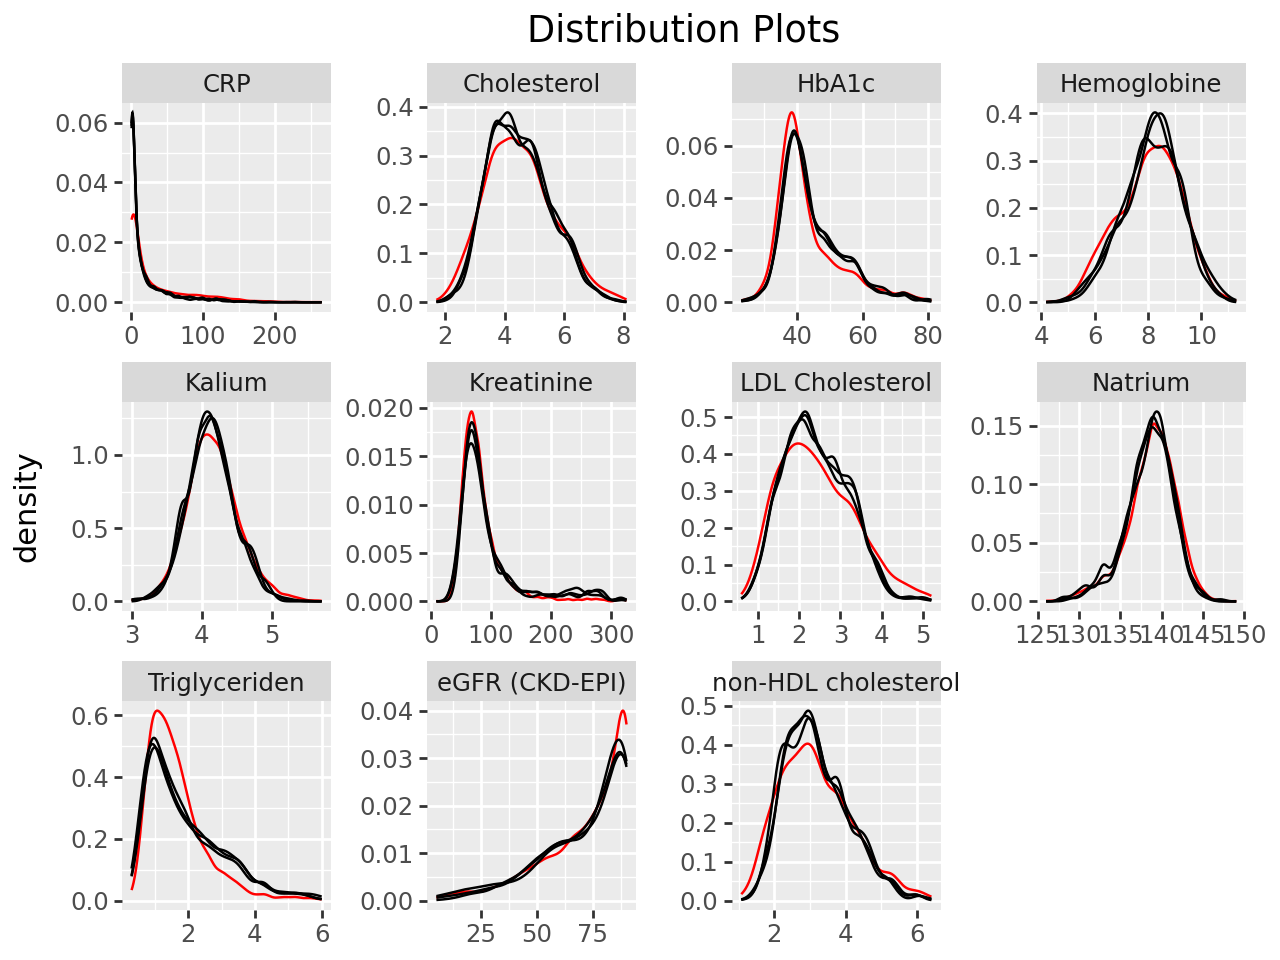

In [50]:
ker.plot_imputed_distributions()

In [52]:
df_p_complete = ker.complete_data()

In [54]:
df_p_complete['HDL Cholesterol'] = df_p_complete['Cholesterol'] - df_p_complete['non-HDL cholesterol'] 

In [58]:
# Set the number of rows and columns for subplots
num_features = df_lab_p_g.select_dtypes(include=[np.number]).columns
num_plots = len(num_features)
rows = (num_plots // 3) + (num_plots % 3 > 0)

# Set up the figure
plt.figure(figsize=(20,int(1.5*rows)))

for i, feature_name in enumerate(num_features):
    plt.subplot(rows, 3, i + 1)
    sns.histplot(df_lab_p_g[feature_name], discrete=False, kde=True, color='#000000', label='Original Data', stat='density',alpha=0)
    sns.histplot(df_p_complete[feature_name], discrete=False, kde=True, color='DarkRed', label='Imputed Data', stat='density', alpha=0)
    plt.title(f'Distribution of {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Density')
    #plt.legend()

plt.tight_layout()
plt.show()

KeyError: 'studyId_0831'